# **Elements of Computing Final Exam_Part 1:** Luxury Dealership Business Use Case using SQLite with Python


---

# **Project Overview**

As the in-house Marketing and Information Specialist for Elite Motor Dealership, you will analyze historical sales data from the `Luxury_Car_Dlrshp.db` database to drive data-led decision-making at the dealership.

# **Your Task:**

* **Step One -** Upload database to notebook environment. (0 pts)
* **Step Two -** Imports and SQLite database connection. (0 pts)
* **Step Three -** Confirm all tables present in database (0 pts)
* **Step Four -** Complete correctly the (5) SQL queries for total revenue and profit KPIs prompts. (5 pts / each)
* **Step Five -** Complete correctly the (3) SQL queries for customer and sales performance prompts. (5 pts / each)
* **Step Six -** Complete correctly the (2) SQL queries for trade-ins and finance analysis prompts. (5 pts / each)

###**For each prompt, you must:**

- **Task 1:** Execute the correct SQL code.

> **Note** - *"correct"*   SQL code is a query that returns an output that completes all elements of the original prompt.

- **Task 2:** Provide a clear answer to the prompt provided for each query based on your returned output.

- **Task 3:** Offer a strategic suggestion for management at Elite Motor Dealership, identifying how these insights (query returns) can improve business KPIs and or reveal new market opportunities.


# **STEP ONE**

*   Upload the `Luxury_Car_Dlrshp.db` into the "Files" section of this notebook.

    **Note** - This file should appear to the left of this cell once successfully added to "Files".

# **STEP TWO**

*   Import all necessary libraries and packages.
*   Establish the path to the DB stored in Files.

In [19]:
import sqlite3
import pandas as pd

# Set the path to the SQLite database
db_path = "./Luxury_Car_Dlrshp.db"

# Connect to SQLite database
conn = sqlite3.connect(db_path)

# Confirmation
print("Connected to SQLite  database!")

Connected to SQLite  database!



# **STEP THREE**

Confirm the database contains the following four tables:

*   `customers`
*   `financials`
*   `sold_vehicles`
*   `trades`

By running the code block below.

In [20]:
# Returns all tables in database

query_tables = """SELECT name
                  FROM sqlite_schema
                  WHERE type='table'
                  ORDER BY name;"""

# Execute the query using pd.read_sql
df_tables = pd.read_sql(query_tables, conn)

print("These are the four tables in the database")
print(df_tables)

These are the four tables in the database
            name
0      customers
1     financials
2  sold_vehicles
3         trades


# **STEP FOUR**

## **Focus:** Total Revenue and Profit KPIs

To begin your analysis complete the prompts below that calculate the revenue and gross profit for the Elite Motors Dealership historical sales data.

> Remember, the definition for "revenue" is defined in the *Definitions* section of the **Luxury Dealership Business Use Case.pdf** resource included in the final project zip file.


## **`Prompts:`**
1.   Total revenue and total gross profit (revenue - cost) from all sold vehicles.
2.   Average gross profit per vehicle sold.
3.   Total number of vehicles sold yearly, for the last 5 years, by year in descending order.
4.   Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.
5.   Total number of sales by inventory type: new `N` and used `U`..



---

`Q1 PROMPT:` Total revenue and total gross profit (revenue - cost) from all sold vehicles.

In [21]:
#Q1 QUERY
query_total_revenue = """
SELECT 
    ROUND(SUM(sale_price), 2) AS Total_Revenue,
    ROUND(SUM(sale_price - total_cost), 2) AS Total_Gross_Profit
FROM financials;
"""

# Run the query and show the results
q1_results = pd.read_sql(query_total_revenue, conn)
q1_results.style.format('${:,.2f}')

,Total_Revenue,Total_Gross_Profit
0,"$267,881,600.58","$251,674,617.65"


`Q1 ANSWER:`
The dealership's total revenue from all sold vehicles was **$267,881,600.58**. The total gross profit, calculated as **sale_price minus total_cost**, was **$251,674,617.65**.


`Q1 ANALYSIS:`
Elite Motor Dealership brought in a very strong amount of total revenue across the updated dataset. What stands out to me is that revenue alone does not tell the full story because the updated data now includes vehicle pack costs for new vehicles and reconditioning costs for used vehicles. My suggestion would be for the dealership to keep tracking gross profit alongside total revenue so they can see which sales are actually creating value after these dealership costs are included. This would help management avoid making decisions based only on sales volume or sale price.

`Q2 PROMPT:` Average gross profit per vehicle sold.


In [22]:
#Q2 QUERY

query_avg_profit = """
SELECT 
    ROUND(AVG(sale_price - total_cost), 2) AS Avg_Gross_Profit_Per_Vehicle
FROM financials;
"""

q2_results = pd.read_sql(query_avg_profit, conn)
q2_results

,Avg_Gross_Profit_Per_Vehicle
0,33228.76


`Q2 ANSWER:`
The average gross profit per vehicle sold is $33,228.76



`Q2 ANALYSIS:`
Management can use this number as a benchmark. Sales below this average should be reviewed for patterns such as weak front-end profit, low financing profit, or costly vehicle prep work.



`Q3 PROMPT:` Total number of vehicles sold yearly, for the last 5 years, by year in descending order.


In [23]:
#Q3 QUERY

query_total_sales = """
SELECT
    strftime('%Y', deal_date) AS sale_year,
    COUNT(*) AS total_sales
FROM financials
GROUP BY sale_year
ORDER BY sale_year DESC
LIMIT 5;
"""

q3_results = pd.read_sql(query_total_sales, conn)
q3_results

,sale_year,total_sales
0,2017,113
1,2016,585
2,2015,572
3,2014,598
4,2013,592


`Q3 ANSWER:`
For the last five years shown in the dataset, total vehicle sales were:

- **2017:** 113 vehicles
- **2016:** 585 vehicles
- **2015:** 572 vehicles
- **2014:** 598 vehicles
- **2013:** 592 vehicles


`Q3 ANALYSIS:`
Sales were fairly steady from 2013 through 2016, staying between **572 and 598 vehicles** each year. The one year that looks different is 2017, which only shows **113 sales**. I would not immediately assume the dealership performed worse in 2017 because that year may be incomplete in the dataset. My suggestion would be to use the complete years, especially 2013 through 2016, as the better baseline for sales goals, staffing, and inventory planning.

`Q4 PROMPT:` Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.


In [24]:
#Q4 QUERY

query_make_sales = """
SELECT
    vehicle_make AS Vehicle_Make,
    COUNT(*)     AS Total_Sales
FROM sold_vehicles
WHERE LOWER(vehicle_make) <> 'lexus'
GROUP BY vehicle_make
ORDER BY Total_Sales DESC
LIMIT 10;
"""

q4_results = pd.read_sql(query_make_sales, conn)
q4_results

,Vehicle_Make,Total_Sales
0,toyota,210
1,honda,96
2,mercedes-benz,87
3,ford,84
4,chevrolet,78
5,bmw,76
6,cadillac,73
7,jeep,71
8,nissan,63
9,chrysler,60


`Q4 ANSWER:`

The top 10 non-Lexus vehicle makes by total sales (count of sales) were:

- **Toyota:** 210
- **Honda:** 96
- **Mercedes-Benz:** 87
- **Ford:** 84
- **Chevrolet:** 78
- **BMW:** 76
- **Cadillac:** 73
- **Jeep:** 71
- **Nissan:** 63
- **Chrysler:** 60

The vehicle make that came in **third highest** was **Mercedes-Benz**, with **87 total sales**.

`Q4 ANALYSIS:`
Even though Lexus is the dealership's main luxury brand, the results show that non-Lexus inventory still matters. Toyota had the highest number of non-Lexus sales, while Mercedes-Benz ranked third and also fits the luxury customer profile. My suggestion would be for the dealership to keep using non-Lexus inventory strategically. Reliable brands like Toyota can bring in practical buyers, while luxury competitors like Mercedes-Benz and BMW can attract customers who want a premium vehicle but may not be set on Lexus.


`Q5 PROMPT:` Total number of sales by inventory type: new `N` and used `U`.


In [25]:
#Q5 QUERY

query_new_used = """
SELECT
    inventory_type,
    COUNT(*) AS total_sales
FROM sold_vehicles
GROUP BY inventory_type
ORDER BY total_sales DESC;
"""

q5_results = pd.read_sql(query_new_used, conn)
q5_results


,inventory_type,total_sales
0,N,3998
1,U,3576


`Q5 ANSWER:`
The dealership sold:

New: 3,998 vehicles
Used: 3,576 vehicles

New vehicles had the higher total sales count.

`Q5 ANALYSIS:`
The dealership sold slightly more new vehicles than used vehicles, but the difference is not huge. This is telling me that both sides of the inventory are important to the business. My suggestion would be to keep a balanced inventory strategy. New vehicles help support the Lexus luxury brand image, while used vehicles help the dealership reach customers who still want quality but may be more price-sensitive. Since the updated data includes vehicle packs for new vehicles and reconditioning costs for used vehicles, the dealership should compare profit by inventory type, not just sales count.



---


# **Customer and Sales Performance:**

To continue your analysis complete these prompts below to identify top customers and sales performance by vehicle category.

## **`Prompts:`**

6.   Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.
7.   Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.
8.   State the most frequent and least frequent contract term types and their total count.

> **Note**, the observation of `1` in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.



`Q6 PROMPT:` Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.


In [26]:
#Q6 QUERY

query_top_customers = """
SELECT
    city     AS City,
    COUNT(*) AS Total_Sales
FROM customers
GROUP BY city
ORDER BY Total_Sales DESC
LIMIT 5;
"""

q6_results = pd.read_sql(query_top_customers, conn)
q6_results

,City,Total_Sales
0,South Bend,1512
1,Granger,946
2,Elkhart,553
3,Mishawaka,516
4,Saint Joseph,251


`Q6 ANSWER:`

The top 5 customer cities by total sales were:

- **South Bend:** 1,512 sales
- **Granger:** 946 sales
- **Elkhart:** 553 sales
- **Mishawaka:** 516 sales
- **Saint Joseph:** 251 sales

The city with the **#1** total sales was **South Bend**, with **1,512 sales**.

`Q6 ANALYSIS:`
All 5 of the top cities are local, which shows that the dealership is mainly selling to customers in the immediate Michiana area. This suggests they have a strong presence locally but may not be reaching customers from farther locations. Because of this, the dealership could try expanding advertising or marketing efforts to nearby cities or regions to bring in more customers and increase total sales.


`Q7 PROMPT:` Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.


In [27]:
# Q7 QUERY

query_postalcodes = """
SELECT
    postal_code AS Postal_Code,
    COUNT(*)    AS Total_Sales
FROM customers
GROUP BY postal_code
ORDER BY Total_Sales DESC
LIMIT 10;
"""

q7_results = pd.read_sql(query_postalcodes, conn)
q7_results

,Postal_Code,Total_Sales
0,46530,945
1,46628,568
2,46514,331
3,46614,324
4,46545,298
5,49085,253
6,49120,221
7,46544,215
8,46637,186
9,46526,160


`Q7 ANSWER:`

The top 10 postal codes by total sales were:

- **46530:** 945
- **46628:** 568
- **46514:** 331
- **46614:** 324
- **46545:** 298
- **49085:** 253
- **49120:** 221
- **46544:** 215
- **46637:** 186
- **46526:** 160

The dealership's postal code, **46545**, had **298 total sales**.

`Q7 ANALYSIS:`
The dealership's own postal code, **46545**, is in the top 10, but it is not the highest-performing postal code. This is useful because it shows that customers are willing to travel from nearby areas to buy vehicles from Elite Motor Dealership. My suggestion would be to focus advertising on the highest-performing postal codes, especially **46530** and **46628**, while still maintaining a strong local presence around **46545** and gradually expanding reach into newer areas. This way the dealership can spend marketing money where it is already seeing the most customer interest, without losing momentum in its home market.


`Q8 PROMPT:` Total sales as `term_total` by contract term type. State the most frequent and least frequent contract term types and their total count.

> Note, the observation of 1 in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.




In [28]:
#Q8 QUERY

query_term_total = """
SELECT
    contract_term,
    COUNT(*) AS term_total
FROM financials
GROUP BY contract_term
ORDER BY term_total DESC;
"""

q8_results = pd.read_sql(query_term_total, conn)
q8_results

,contract_term,term_total
0,1,4497
1,60,1297
2,36,792
3,48,615
4,72,114
5,24,72
6,66,37
7,39,31
8,42,21
9,75,17


`Q8 ANSWER:`
The most frequent contract term was 1, with 4,497 total sales. Since a contract term of 1 means the customer paid in cash, cash purchases were the most common transaction type.

The least frequent contract term was 69, with 2 total sales.

`Q8 ANALYSIS:`
The most common contract term was 1, meaning many customers paid in cash instead of using a longer loan. That makes sense for a luxury dealership because some customers may have higher purchasing power. My suggestion would be to still promote financing options clearly, especially for customers who want a luxury vehicle but would rather spread out payments. The dealership could also compare cash deals against financed deals to see which type creates more frontend or backend profit.


# **Trade-ins and Finance Analysis:**

To finalize your analysis complete these prompts below to identify the financial impact of trades on the overall gross profit for the dealership.

## **`Prompts:`**

9.   Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.

10.  Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

`Q9 PROMPT:` Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.






In [29]:
#Q9 QUERY

query_trade_count = """
SELECT
    COUNT(*) AS total_trade_ins
FROM trades
WHERE trade_vin <> 'Not Applicable';
"""

q9_results = pd.read_sql(query_trade_count, conn)
q9_results


,total_trade_ins
0,2965


`Q9 ANSWER:`
There were 2,965 trade-in vehicles in the dataset.


`Q9 ANALYSIS:`
Trade-ins were a major part of the dealership's sales process. Since 2,965 sales involved a trade-in, the dealership should treat trade-ins as both a customer conversion tool and a source of used inventory. My suggestion would be to make trade-in offers a bigger part of marketing through online estimates, appraisal events, and simple messaging that shows customers how their current vehicle can help lower the cost of their next purchase.

`Q10 PROMPT:` Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

In [30]:
#Q10 QUERY

query_profit = """
SELECT
    CASE
        WHEN t.trade_vin <> 'Not Applicable' THEN 'With Trade-In'
        ELSE 'Without Trade-In'
    END                                          AS Trade_Status,
    ROUND(AVG(f.sale_price - f.total_cost), 2)   AS Avg_Profitability,
    COUNT(*)                                     AS Total_Sales
FROM financials AS f
INNER JOIN sold_vehicles AS sv
    ON f.deal_vin = sv.deal_vin
INNER JOIN trades AS t
    ON sv.deal_number = t.trade_number
GROUP BY Trade_Status
ORDER BY Avg_Profitability DESC;
"""

q10_results = pd.read_sql(query_profit, conn)
q10_results

,Trade_Status,Avg_Profitability,Total_Sales
0,With Trade-In,36025.88,3963
1,Without Trade-In,30832.61,5663


`Q10 ANSWER:`
The average profitability was:

- With Trade-In: $36,025.88 across 3,963 sales
- Without Trade-In: $30,832.61 across 5,663 sales

Sales with a trade-in had the higher average profitability.

`Q10 ANALYSIS:`
Sales with trade-ins were more profitable on average than sales without trade-ins. This suggests that trade-ins may create extra value for the dealership through resale opportunities, pricing flexibility, or stronger deal structure. My suggestion would be for the dealership to encourage more trade-ins through appraisal events, online trade-in estimates, and promotions that make customers feel comfortable bringing in their current vehicle. Since trade-in deals had higher average profitability, this could be one of the strongest opportunities for improving dealership performance.

---

# Part 2: Advanced Visualizations



## Visualization #1: Gross Profit Distribution by Inventory Type and Trade-In Status

**What I'm investigating:** Q5 showed the difference between new and used vehicle sales volume, and Q10 showed the average profit for trade-in vs. no-trade deals. However, averages can hide the full spread of the data. This violin plot helps show whether groups have similar average profits but very different distributions, which matters for understanding pricing risk and profit consistency.


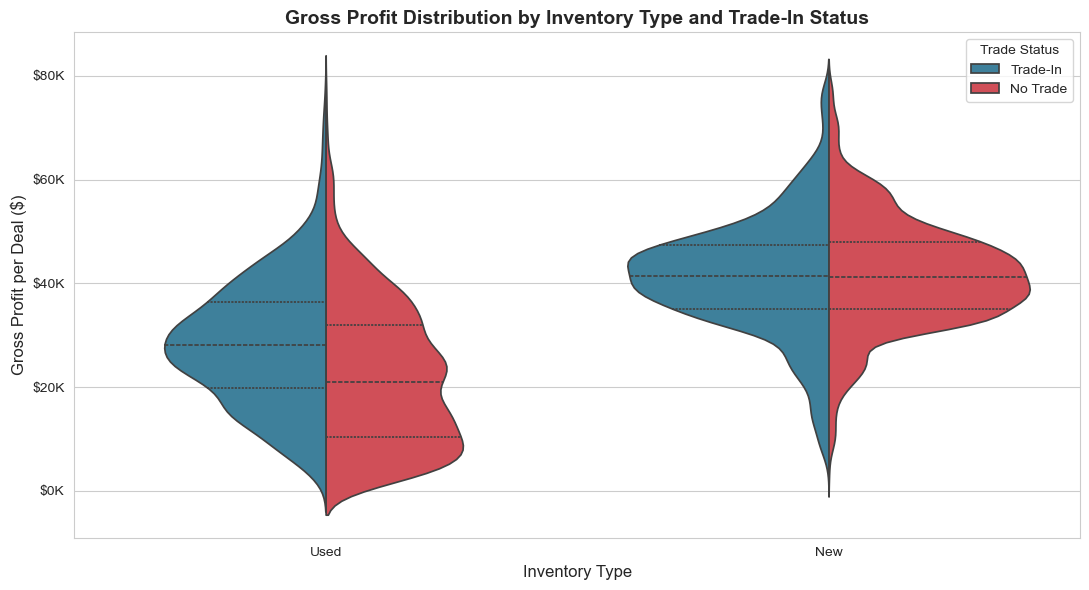

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pulling the data 
viz_query = """
SELECT 
    sv.inventory_type,
    f.sale_price,
    (f.sale_price - f.total_cost) AS gross_profit,
    CASE 
        WHEN t.trade_vin = 'Not Applicable' THEN 'No Trade'
        ELSE 'Trade-In'
    END AS trade_status
FROM financials AS f
INNER JOIN sold_vehicles AS sv 
    ON f.deal_vin = sv.deal_vin
INNER JOIN trades AS t 
    ON sv.deal_number = t.trade_number
"""
viz_df = pd.read_sql(viz_query, conn)

# Make inventory labels easier to read
viz_df['Inventory'] = viz_df['inventory_type'].map({'N': 'New', 'U': 'Used'})

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

# Filter extreme outliers so the violin plot is easier to read
plot_df = viz_df[
    (viz_df['gross_profit'] > viz_df['gross_profit'].quantile(0.005)) &
    (viz_df['gross_profit'] < viz_df['gross_profit'].quantile(0.995))
]

sns.violinplot(
    data=plot_df,
    x='Inventory',
    y='gross_profit',
    hue='trade_status',
    split=True,
    inner='quartile',
    palette={'Trade-In': '#2E86AB', 'No Trade': '#E63946'},
    ax=ax
)

ax.set_title(
    'Gross Profit Distribution by Inventory Type and Trade-In Status',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Inventory Type', fontsize=12)
ax.set_ylabel('Gross Profit per Deal ($)', fontsize=12)
ax.legend(title='Trade Status', loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
    
plt.tight_layout()
plt.show()

This violin plot compares the distribution of gross profit for new and used vehicles. I also split each group by whether the deal had a trade-in or no trade-in. I wanted to go beyond the averages from Q5 and Q10 because averages do not always show how spread out or consistent the profits really are.

**What I found:**  
The plot shows that new vehicles usually have higher gross profit than used vehicles. New vehicle profits are mostly centered around the $40K range, while used vehicles are more spread out and often lower. For used vehicles, there is also a bigger difference between trade-in and no-trade deals, which shows that trade-ins may affect profit consistency more for used inventory.

For Elite Motor Dealership, this matters because the dealership should not only look at average profit. A group can have a good average but still include a lot of inconsistent or lower-profit deals. Based on this, the dealership should review how trade-ins are valued, especially for used vehicles. Since used vehicles can also have reconditioning costs, better trade-in appraisal and pricing standards could help make profits more consistent.

## Visualization #2: Monthly Sales Volume of New vs. Used Vehicles Over Time

**What I'm investigating:** Q3 showed that yearly sales were fairly steady, but yearly numbers can hide month-to-month patterns. I wanted to look at monthly sales for new and used vehicles separately to see whether the two groups follow the same seasonal trend or whether one type of inventory sells differently throughout the year. Actually from data-to-viz.com I found that a line chart with multiple time series is the right choice when comparing the evolution of two or more groups over time, and adding a rolling average helps reveal the underlying trend without losing the monthly detail.

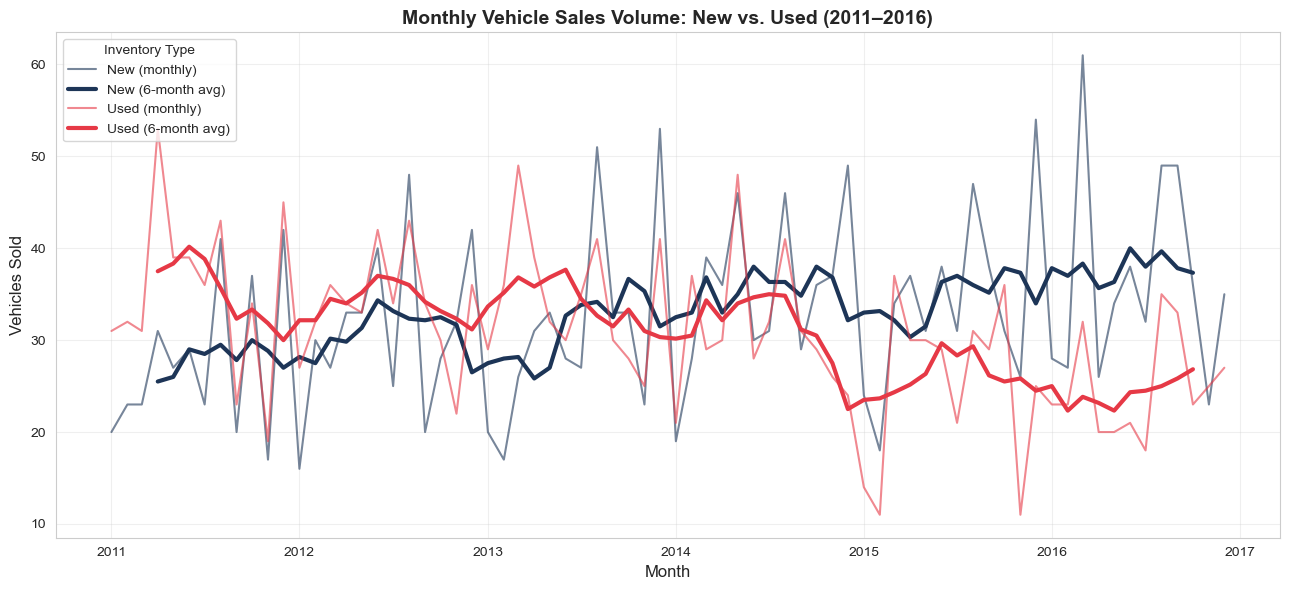

In [32]:
import matplotlib.pyplot as plt

# Pull monthly sales data split by inventory type
monthly_query = """
SELECT 
    strftime('%Y-%m', f.deal_date) AS sale_month,
    sv.inventory_type,
    COUNT(*) AS vehicles_sold
FROM financials AS f
INNER JOIN sold_vehicles AS sv 
    ON f.deal_vin = sv.deal_vin
GROUP BY sale_month, sv.inventory_type
ORDER BY sale_month;
"""

monthly_df = pd.read_sql(monthly_query, conn)

# Convert month to datetime and make inventory labels easier to read
monthly_df['sale_month'] = pd.to_datetime(monthly_df['sale_month'])
monthly_df['Inventory'] = monthly_df['inventory_type'].map({'N': 'New', 'U': 'Used'})

# Focus on complete years so the trend is not affected by partial-year data
monthly_df = monthly_df[
    (monthly_df['sale_month'] >= '2011-01-01') &
    (monthly_df['sale_month'] < '2017-01-01')
].sort_values('sale_month')

fig, ax = plt.subplots(figsize=(13, 6))

# Plot monthly sales and a 6-month rolling average for each inventory type
for inv_label, color in [('New', '#1D3557'), ('Used', '#E63946')]:
    sub = monthly_df[monthly_df['Inventory'] == inv_label].sort_values('sale_month')
    
    ax.plot(
        sub['sale_month'],
        sub['vehicles_sold'],
        label=f'{inv_label} (monthly)',
        color=color,
        linewidth=1.5,
        alpha=0.6
    )
    
    rolling = sub.set_index('sale_month')['vehicles_sold'].rolling(
        window=6,
        center=True
    ).mean()
    
    ax.plot(
        rolling.index,
        rolling.values,
        label=f'{inv_label} (6-month avg)',
        color=color,
        linewidth=3,
        alpha=1.0
    )

ax.set_title(
    'Monthly Vehicle Sales Volume: New vs. Used (2011–2016)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Vehicles Sold', fontsize=12)
ax.legend(title='Inventory Type', loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What I found:**  
This chart shows that monthly sales moved around a lot more than the yearly totals from Q3 made it seem. The rolling average helps make the overall trend easier to see because it smooths out the month-to-month changes. From 2011 to about 2014, new and used vehicle sales followed a pretty similar pattern. Around late 2014, though, the two trends started to separate. New vehicle sales started moving upward through 2016, while used vehicle sales dropped to lower volumes by the end of the period.

For Elite Motor Dealership, this matters because yearly totals can make sales look steady even when important changes are happening within the year. The split between new and used vehicles around 2015 is something management should look into more. It could be from a strategy change, inventory changes, or a shift in the market. Looking at monthly trends can help the dealership plan inventory, marketing, and staffing better. Since used vehicle sales became lower and less consistent, the dealership may need to manage used inventory more carefully so those vehicles do not sit too long on the lot.

## Visualization #3: Sale Price vs. Gross Profit, Faceted by Inventory Type

**What I’m investigating:**  
Q5 and Q10 looked at counts and averages, but neither one showed how sale price is actually related to gross profit. I wanted to see whether higher-priced vehicles tend to bring in higher profit at the same rate for both new and used inventory, or whether that relationship looks different depending on the inventory type. A scatter plot is a good choice here because it shows the relationship between two numeric variables, and faceting helps compare that relationship side by side for new versus used vehicles.

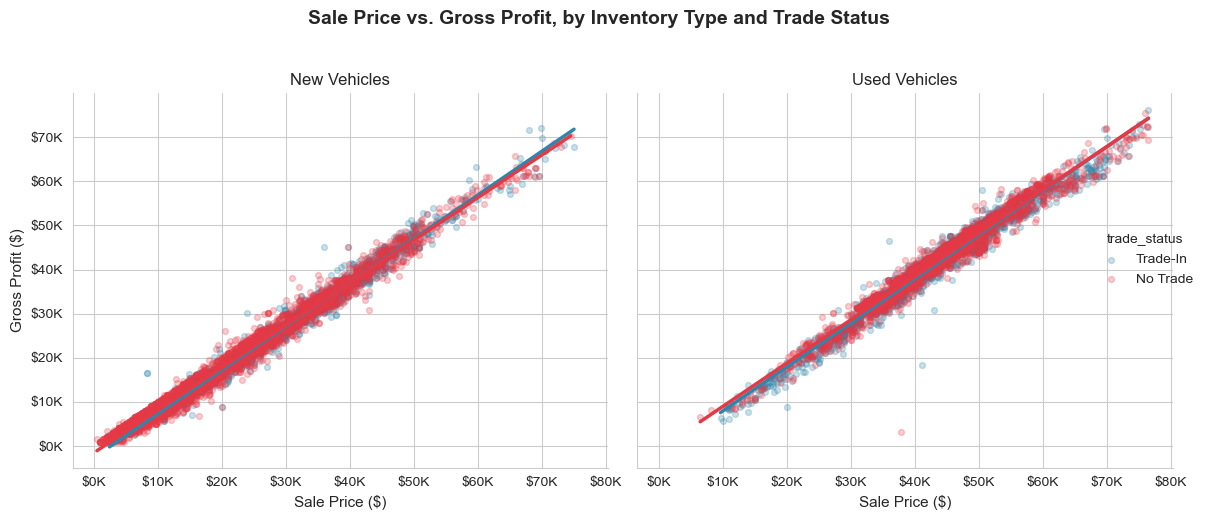

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pull data for the visualization
viz3_query = """
SELECT 
    sv.inventory_type,
    f.sale_price,
    (f.sale_price - f.total_cost) AS gross_profit,
    CASE 
        WHEN t.trade_vin = 'Not Applicable' THEN 'No Trade'
        ELSE 'Trade-In'
    END AS trade_status
FROM financials AS f
INNER JOIN sold_vehicles AS sv 
    ON f.deal_vin = sv.deal_vin
INNER JOIN trades AS t 
    ON sv.deal_number = t.trade_number
"""

viz3_df = pd.read_sql(viz3_query, conn)
viz3_df['Inventory'] = viz3_df['inventory_type'].map({'N': 'New', 'U': 'Used'})

# Filter outliers so the chart is readable
plot_df = viz3_df[
    (viz3_df['sale_price'] > 0) &
    (viz3_df['sale_price'] < viz3_df['sale_price'].quantile(0.99)) &
    (viz3_df['gross_profit'] > viz3_df['gross_profit'].quantile(0.005)) &
    (viz3_df['gross_profit'] < viz3_df['gross_profit'].quantile(0.995))
].copy()

# Use seaborn's lmplot for faceted scatter with regression lines
g = sns.lmplot(
    data=plot_df,
    x='sale_price',
    y='gross_profit',
    col='Inventory',
    hue='trade_status',
    palette={'Trade-In': '#2E86AB', 'No Trade': '#E63946'},
    scatter_kws={'alpha': 0.25, 's': 18},
    line_kws={'linewidth': 2.5},
    height=5,
    aspect=1.1,
    ci=None
)

g.fig.suptitle(
    'Sale Price vs. Gross Profit, by Inventory Type and Trade Status',
    fontsize=14,
    fontweight='bold',
    y=1.03
)

for ax, title in zip(g.axes.flat, ['New Vehicles', 'Used Vehicles']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Sale Price ($)', fontsize=11)
    ax.set_ylabel('Gross Profit ($)', fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

**What I found:** This scatter plot shows a really strong positive relationship between sale price and gross profit. As sale price increases, gross profit also increases for both new and used vehicles. Most of the points are close to the trend line, so the relationship looks pretty consistent overall. The faceted view helps because it separates new and used vehicles instead of putting everything into one chart. Both groups follow a similar pattern, but used vehicles have a little more spread and a few more unusual points. This makes sense because used vehicles can vary more from deal to deal because of trade-in values, reconditioning costs, and pricing decisions. Looking at the colors, trade-in deals seem to sit slightly higher than no-trade deals at similar sale prices, which also connects back to what I found in Q10. For Elite Motor Dealership, this matters because higher sale prices usually lead to higher gross profit, but the dealership should still pay attention to the exceptions. Used vehicles especially should be reviewed more closely because they are less consistent than new vehicles. A good next step would be to look at used vehicle deals that fall below the main trend line and see whether reconditioning costs, trade-in values, or pricing decisions are lowering profit on those deals.